# Phase 3 — Multi-Objective Budget Optimization
### AI-Assisted Equity-Aware Budget Allocation Framework for Panchayats

**Run this AFTER notebook 05.** It reads `phase2_final_predictions.csv` (165 GP-sector rows with predicted impact, need scores, and uncertainty) and solves the budget-allocation problem from Section 7 of the research document using **NSGA-II** (the multi-objective algorithm your document names alongside PSO).

**What this notebook produces:**
1. A Pareto front of allocation solutions — no single "optimal" answer, by design (the document explicitly says to avoid presenting one mathematically optimal solution as universally correct).
2. Four named scenarios pulled from that front — Impact-first, Need-first, Equity-first, Balanced — matching the exact scenario names in Section 12 of the research document's evaluation table.
3. A per-scenario allocation table (how much money goes to every GP-sector pair) and a summary comparison table (budget utilization, total impact, unmet need, equity).
4. A Pareto-front chart showing the real trade-off between impact and equity.

---
### Modeling assumptions made explicit (read before trusting the numbers)

Two simplifications were necessary to make this runnable today, and both are documented here rather than hidden:

1. **Impact-vs-partial-budget relationship.** Phase 2's model predicts impact only *for the full proposed budget* of each project — it was never trained on varying budget amounts for the same project. This notebook assumes impact scales **proportionally** with the funding fraction: `impact(a) = predicted_impact × (a / proposed_budget)`. This is a standard simplifying assumption for a first working optimizer, not a validated relationship. The real fix — training Phase 2's model on multiple budget levels per project so it can answer "what if we fund this at 60% instead of 100%?" — is listed as next-step work in Section 6.

2. **Three objectives, not four.** The document lists four objectives: maximize impact (F1), maximize need-weighted impact (F2), minimize unmet need (F3), and promote equity (F4). F3 (unmet need) is **highly correlated** with F1/F2 here (less funding directly means more unmet need under the proportional-impact assumption), so running all four through NSGA-II would mostly duplicate objectives without adding real trade-off information. This notebook optimizes F1, F2, and F4 directly, and reports F3 as a **derived metric** in the results table for every scenario rather than a fourth optimization target. This is a defensible scoping decision for a first version — revisit it once real project data breaks the F1/F3 correlation.


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from pymoo.core.problem import Problem
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.optimize import minimize
    from pymoo.operators.sampling.rnd import FloatRandomSampling
    from pymoo.operators.crossover.sbx import SBX
    from pymoo.operators.mutation.pm import PM
except ImportError:
    !pip install pymoo -q
    from pymoo.core.problem import Problem
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.optimize import minimize
    from pymoo.operators.sampling.rnd import FloatRandomSampling
    from pymoo.operators.crossover.sbx import SBX
    from pymoo.operators.mutation.pm import PM

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned")

np.random.seed(42)
print("Setup complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.2/347.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.1 MB/s eta 0:00:00
Setup complete.


## 2. Load Phase 2 predictions and set up the problem

`c` = the project cost cap per GP-sector (`proposed_budget_lakh` — the maximum that could be usefully allocated). `B` = the total available budget. Set here to **60% of total requested funding**, which forces genuine trade-offs (at 100% there's nothing to optimize, everyone gets everything). **Change `BUDGET_FRACTION` to match your actual scheme budget once you know it.**

In [ ]:
pred_file = os.path.join(CLEAN_DIR, "phase2_final_predictions.csv")
pred_df = pd.read_csv(pred_file)
print("Loaded predictions:", pred_df.shape)
assert pred_df.shape[0] == 198, "Expected 198 GP-sector rows -- rerun notebook 05 if this fails"

n = len(pred_df)
c = pred_df["proposed_budget_lakh"].values
impact_full = pred_df["predicted_impact"].values
need = pred_df["sector_need_score"].values

BUDGET_FRACTION = 0.6   # <-- CHANGE THIS once you know your real available budget
TOTAL_PROPOSED = c.sum()
B = BUDGET_FRACTION * TOTAL_PROPOSED

print(f"Total proposed across all {n} projects: {TOTAL_PROPOSED:.1f} lakh")
print(f"Available budget B: {B:.1f} lakh ({BUDGET_FRACTION:.0%} of requested)")


Loaded predictions: (198, 12)
Total proposed across all 198 projects: 2724.6 lakh
Available budget B: 1634.8 lakh (60% of requested)


## 3. Define the optimization problem

Decision variable: `a_{i,s}`, one continuous value per GP-sector project, bounded `0 <= a_{i,s} <= c_{i,s}`.

Objectives (all converted to minimization for NSGA-II, since impact/need are maximized by negating):
- **F1** — maximize total predicted impact: `-sum(impact(a))`
- **F2** — maximize need-weighted impact (prioritizes high-need GPs): `-sum(need * impact(a))`
- **F4** — minimize inequality in need-satisfaction across GPs, via the Gini coefficient of `a/c` (the funded fraction of each project)

Constraint: `sum(a) <= B`.

In [ ]:
def gini(x):
    """Standard Gini coefficient, 0 = perfectly equal, 1 = maximally unequal."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n


class BudgetAllocationProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=n, n_obj=3, n_constr=1,
            xl=np.zeros(n), xu=c.copy(),
        )

    def _evaluate(self, X, out, *args, **kwargs):
        # X shape: (population_size, n) -- each row is one candidate allocation vector
        frac = np.divide(X, c, out=np.zeros_like(X), where=c > 0)
        impact = impact_full[None, :] * frac   # proportional impact assumption -- see notebook intro

        f1 = -impact.sum(axis=1)
        f2 = -(need[None, :] * impact).sum(axis=1)
        f4 = np.array([gini(row) for row in frac])

        g1 = X.sum(axis=1) - B   # <= 0 required

        out["F"] = np.column_stack([f1, f2, f4])
        out["G"] = g1.reshape(-1, 1)


problem = BudgetAllocationProblem()
print("Problem defined:", n, "decision variables, 3 objectives, 1 budget constraint.")


Problem defined: 198 decision variables, 3 objectives, 1 budget constraint.


## 4. Run NSGA-II

`pop_size=100`, `n_gen=80` runs in well under a minute for this problem size. Increase `n_gen` if the Pareto front looks under-converged (check that objective values stop improving in later generations).

In [ ]:
algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
)

res = minimize(problem, algorithm, ("n_gen", 80), seed=42, verbose=False)

feasible = res.G[:, 0] <= 1e-6
print(f"Pareto front solutions found: {len(res.X)}")
print(f"Feasible (budget-respecting) solutions: {feasible.sum()}/{len(res.X)}")

assert feasible.sum() > 0, "No feasible solutions found -- check budget B is not set too low"


Pareto front solutions found: 54
Feasible (budget-respecting) solutions: 54/54


## 5. Pick out four named scenarios from the Pareto front

Matches the exact scenario names in Section 12 of the research document's "Allocation evaluation" table: Impact-first, (Need-first — an extension of the document's naming, since F2 is a distinct objective here), Equity-first, and Balanced (closest point to the ideal corner of the normalized objective space).

In [ ]:
F = res.F
X = res.X

impact_first_idx = np.argmin(F[:, 0])
need_first_idx = np.argmin(F[:, 1])
equity_first_idx = np.argmin(F[:, 2])

# Balanced: normalize each objective to [0,1], pick the point closest to the ideal (best-of-each) corner
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-9)
ideal = F_norm.min(axis=0)
dist_to_ideal = np.linalg.norm(F_norm - ideal, axis=1)
balanced_idx = np.argmin(dist_to_ideal)

scenarios = {
    "Impact-first": impact_first_idx,
    "Need-first": need_first_idx,
    "Equity-first": equity_first_idx,
    "Balanced": balanced_idx,
}
print("Selected scenario indices:", scenarios)


Selected scenario indices: {'Impact-first': np.int64(53), 'Need-first': np.int64(45), 'Equity-first': np.int64(50), 'Balanced': np.int64(44)}


## 6. Build the allocation table and the evaluation summary (Section 12 format)

In [ ]:
alloc_df = pred_df[["gp_name", "sector", "proposed_budget_lakh", "sector_need_score", "predicted_impact"]].copy()

summary_rows = []
for name, idx in scenarios.items():
    a = X[idx]
    frac = np.divide(a, c, out=np.zeros_like(a), where=c > 0)
    impact = impact_full * frac
    unmet_need = (need * (1 - frac)).sum()   # derived F3 metric, not directly optimized -- see notebook intro

    summary_rows.append({
        "scenario": name,
        "budget_utilization_pct": round(100 * a.sum() / B, 1),
        "total_impact": round(impact.sum(), 2),
        "need_weighted_impact": round((need * impact).sum(), 2),
        "unmet_need": round(unmet_need, 2),
        "gini_inequality": round(gini(frac), 4),
    })

    col_name = f"allocation_{name.lower().replace('-', '_')}_lakh"
    alloc_df[col_name] = np.round(a, 2)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,scenario,budget_utilization_pct,total_impact,need_weighted_impact,unmet_need,gini_inequality
0,Impact-first,100.0,46.78,26.28,19.90,0.2031
1,Need-first,99.8,46.77,26.29,19.90,0.2082
2,Equity-first,99.0,44.69,24.02,23.86,0.1570
3,Balanced,99.9,46.48,25.83,20.53,0.1809


In [ ]:
summary_file = os.path.join(CLEAN_DIR, "phase3_scenario_summary.csv")
alloc_file = os.path.join(CLEAN_DIR, "phase3_allocations_by_scenario.csv")

summary_df.to_csv(summary_file, index=False)
alloc_df.to_csv(alloc_file, index=False)

print("Saved:", summary_file)
print("Saved:", alloc_file, "--", len(alloc_df), "rows (all 198 GP-sector allocations x 4 scenarios)")

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase3_scenario_summary.csv
Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase3_allocations_by_scenario.csv -- 198 rows (all 198 GP-sector allocations x 4 scenarios)


## 7. Pareto front chart — the real trade-off

This is the chart that visually proves there is no single "best" answer: pushing for more total impact (right side) generally costs you equity (color), and vice versa. This is the honest output of a multi-objective problem, and the research document explicitly wants this presented as alternatives, not one number.

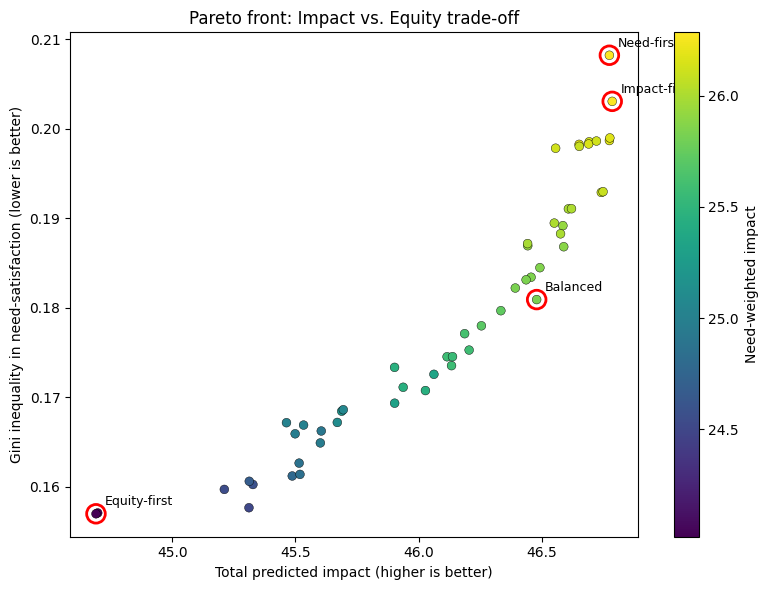

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase3_pareto_front.png


In [ ]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(-F[:, 0], F[:, 2], c=-F[:, 1], cmap="viridis", s=40, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, label="Need-weighted impact")

for name, idx in scenarios.items():
    plt.scatter(-F[idx, 0], F[idx, 2], s=180, facecolors="none", edgecolors="red", linewidth=2)
    plt.annotate(name, (-F[idx, 0], F[idx, 2]), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel("Total predicted impact (higher is better)")
plt.ylabel("Gini inequality in need-satisfaction (lower is better)")
plt.title("Pareto front: Impact vs. Equity trade-off")
plt.tight_layout()

chart_file = os.path.join(CLEAN_DIR, "phase3_pareto_front.png")
plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", chart_file)


## 8. Handoff notes — Phase 3 baseline complete

**Files saved to `Cleaned/`, ready for GitHub:**
- `phase3_scenario_summary.csv` — the 4-scenario comparison table (matches Section 12's evaluation table format)
- `phase3_allocations_by_scenario.csv` — full 165-row allocation amounts for all 4 scenarios
- `phase3_pareto_front.png` — the impact-vs-equity trade-off chart

**What's still open (documented, not hidden):**
- **Proportional impact assumption** (Section 3) — the biggest thing to fix. Once Phase 2 has a model that predicts impact *as a function of funding level* (not just at the full requested amount), swap it in here instead of the linear scaling shortcut.
- **F3 (unmet need) is reported, not optimized** — revisit if real data makes it diverge from F1/F2.
- **`BUDGET_FRACTION = 0.6`** is a placeholder. Replace with the real available scheme budget as soon as it's known — every number in the summary table shifts with it.
- **Sensitivity analysis** (Section 9, Phase 3 step 7 of the methodology) — rerun this notebook at a few different `BUDGET_FRACTION` values (e.g. 0.4, 0.6, 0.8) and compare how the scenario summaries shift, for the paper's sensitivity section.

**Next: Phase 4** — explainability (SHAP) and governance. The allocation decisions and the Phase 2 predictions they're built on are now both sitting in `Cleaned/`, ready for SHAP to explain *why* a given GP-sector got the allocation it did.



--- Budget fraction: 40% ---
Available budget: 1089.84 lakh
Feasible solutions: 53

--- Budget fraction: 60% ---
Available budget: 1634.76 lakh
Feasible solutions: 54

--- Budget fraction: 80% ---
Available budget: 2179.68 lakh
Feasible solutions: 22

SENSITIVITY ANALYSIS RESULTS


,budget_fraction,budget_lakh,total_allocated_lakh,budget_utilization_pct,total_predicted_impact,need_weighted_impact,unmet_need,gini_inequality
0,0.4,1089.84,1089.10,99.93,33.3004,19.3386,34.1965,0.2906
1,0.6,1634.76,1633.24,99.91,46.4781,25.8278,20.5295,0.1809
2,0.8,2179.68,2177.52,99.90,57.0788,29.6668,12.0856,0.0932



Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase3_sensitivity_analysis.csv


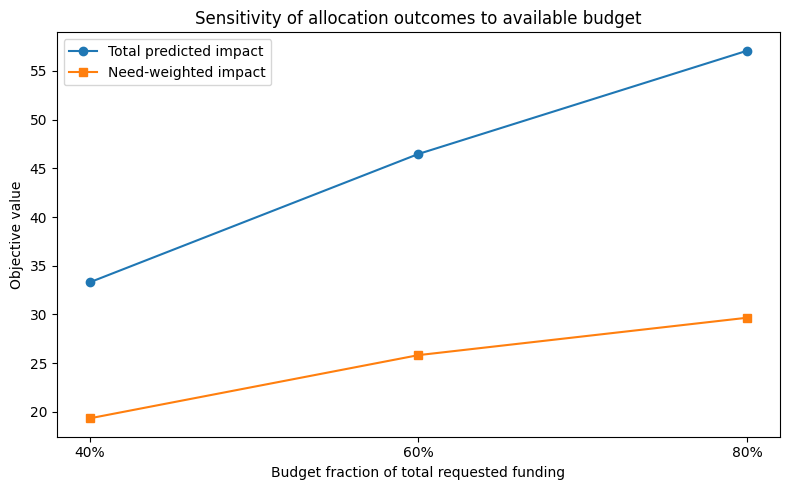

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase3_sensitivity_chart.png


In [ ]:
# ============================================================
# 8. SENSITIVITY ANALYSIS — DIFFERENT AVAILABLE BUDGETS
# ============================================================
# Tests how the allocation changes when the available budget
# is 40%, 60%, and 80% of the total requested funding.
#
# IMPORTANT:
# BudgetAllocationProblem() uses the global variable B.
# Therefore, we temporarily change B before creating
# each problem instance.
# ============================================================

BUDGET_FRACTIONS_TO_TEST = [0.4, 0.6, 0.8]

sensitivity_results = []

# Save the original budget so we can restore it afterward
original_B = B
original_budget_fraction = BUDGET_FRACTION

for frac in BUDGET_FRACTIONS_TO_TEST:

    # Set budget for this sensitivity scenario
    B = frac * TOTAL_PROPOSED

    print(f"\n--- Budget fraction: {frac:.0%} ---")
    print(f"Available budget: {B:.2f} lakh")

    # Re-create the optimization problem using the new B
    problem_test = BudgetAllocationProblem()

    # Run NSGA-II
    algorithm_test = NSGA2(
        pop_size=100,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
    )

    res_test = minimize(
        problem_test,
        algorithm_test,
        ("n_gen", 80),
        seed=42,
        verbose=False
    )

    # Keep feasible solutions only
    feasible_test = res_test.G[:, 0] <= 1e-6

    F_test = res_test.F[feasible_test]
    X_test = res_test.X[feasible_test]

    print(f"Feasible solutions: {len(X_test)}")

    if len(X_test) == 0:
        print("WARNING: No feasible solution found for this budget.")
        continue

    # --------------------------------------------------------
    # Select a balanced solution
    # Same logic used in the main optimization
    # --------------------------------------------------------
    F_norm_test = (
        (F_test - F_test.min(axis=0))
        /
        (F_test.max(axis=0) - F_test.min(axis=0) + 1e-9)
    )

    ideal_test = F_norm_test.min(axis=0)

    dist_to_ideal_test = np.linalg.norm(
        F_norm_test - ideal_test,
        axis=1
    )

    balanced_idx_test = np.argmin(dist_to_ideal_test)

    alloc_test = X_test[balanced_idx_test]

    # --------------------------------------------------------
    # Calculate evaluation metrics
    # --------------------------------------------------------
    frac_alloc = np.divide(
        alloc_test,
        c,
        out=np.zeros_like(alloc_test),
        where=c > 0
    )

    impact_test = impact_full * frac_alloc

    unmet_need_test = (
        need * (1 - frac_alloc)
    ).sum()

    total_impact_test = impact_test.sum()

    need_weighted_impact_test = (
        need * impact_test
    ).sum()

    gini_test = gini(frac_alloc)

    utilization_test = (
        alloc_test.sum() / B * 100
    )

    sensitivity_results.append({
        "budget_fraction": frac,
        "budget_lakh": round(B, 2),
        "total_allocated_lakh": round(alloc_test.sum(), 2),
        "budget_utilization_pct": round(utilization_test, 2),
        "total_predicted_impact": round(total_impact_test, 4),
        "need_weighted_impact": round(need_weighted_impact_test, 4),
        "unmet_need": round(unmet_need_test, 4),
        "gini_inequality": round(gini_test, 4),
    })


# ------------------------------------------------------------
# Restore original budget
# ------------------------------------------------------------
B = original_B
BUDGET_FRACTION = original_budget_fraction


# ------------------------------------------------------------
# Create sensitivity table
# ------------------------------------------------------------
sensitivity_df = pd.DataFrame(sensitivity_results)

print("\n========================================")
print("SENSITIVITY ANALYSIS RESULTS")
print("========================================")

display(sensitivity_df)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
sensitivity_file = os.path.join(
    CLEAN_DIR,
    "phase3_sensitivity_analysis.csv"
)

sensitivity_df.to_csv(
    sensitivity_file,
    index=False
)

print("\nSaved:", sensitivity_file)


# ------------------------------------------------------------
# Plot sensitivity of predicted impact
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity_df["budget_fraction"],
    sensitivity_df["total_predicted_impact"],
    marker="o",
    label="Total predicted impact"
)

plt.plot(
    sensitivity_df["budget_fraction"],
    sensitivity_df["need_weighted_impact"],
    marker="s",
    label="Need-weighted impact"
)

plt.xlabel("Budget fraction of total requested funding")
plt.ylabel("Objective value")
plt.title("Sensitivity of allocation outcomes to available budget")

plt.xticks(
    BUDGET_FRACTIONS_TO_TEST,
    ["40%", "60%", "80%"]
)

plt.legend()
plt.tight_layout()

sensitivity_chart_file = os.path.join(
    CLEAN_DIR,
    "phase3_sensitivity_chart.png"
)

plt.savefig(
    sensitivity_chart_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", sensitivity_chart_file)